# 9. Model deployment 

### 0.Getting setup

In [1]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms
from torchinfo import summary
from helper_functions import download_data, set_seeds, plot_loss_curves
import data_setup, engine
from pathlib import Path

In [2]:
print(torch.__version__)

2.5.1+cu121


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 2. Get data

In [4]:
data_20_percent_path = Path("C:/Free code camp/fcc ml/07_pytorch_exp_tracking/data/pizza_steak_sushi_20_percent")
train_dir = data_20_percent_path/ "train" 
test_dir = data_20_percent_path/ "test" 

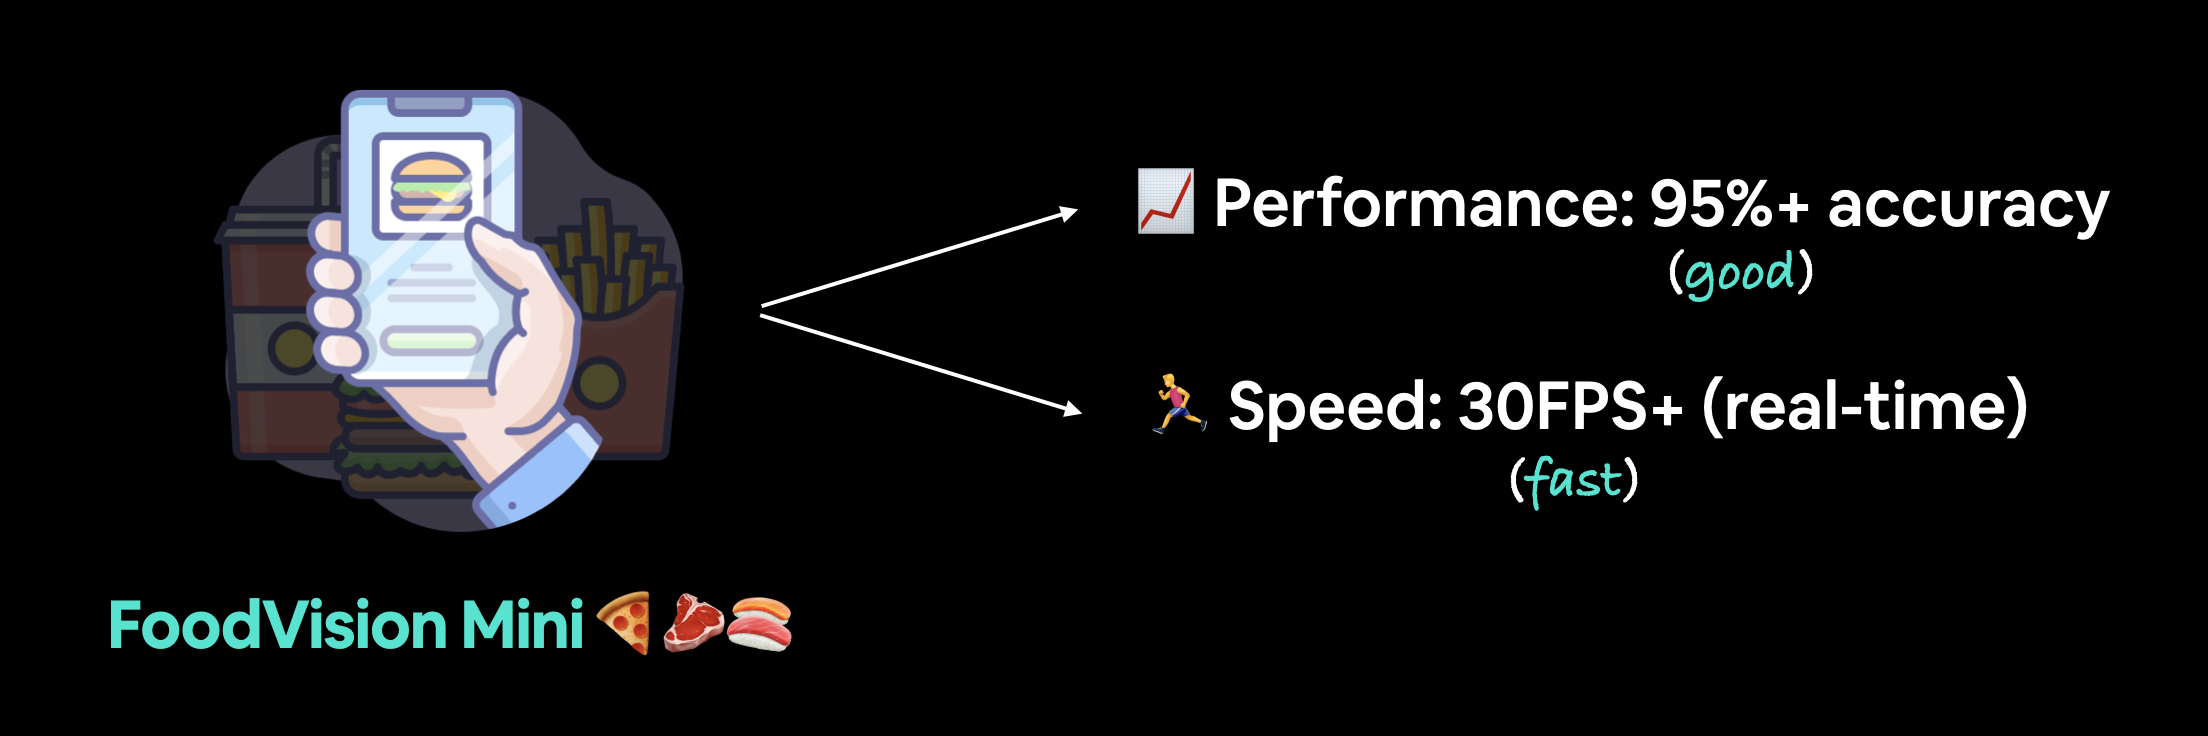

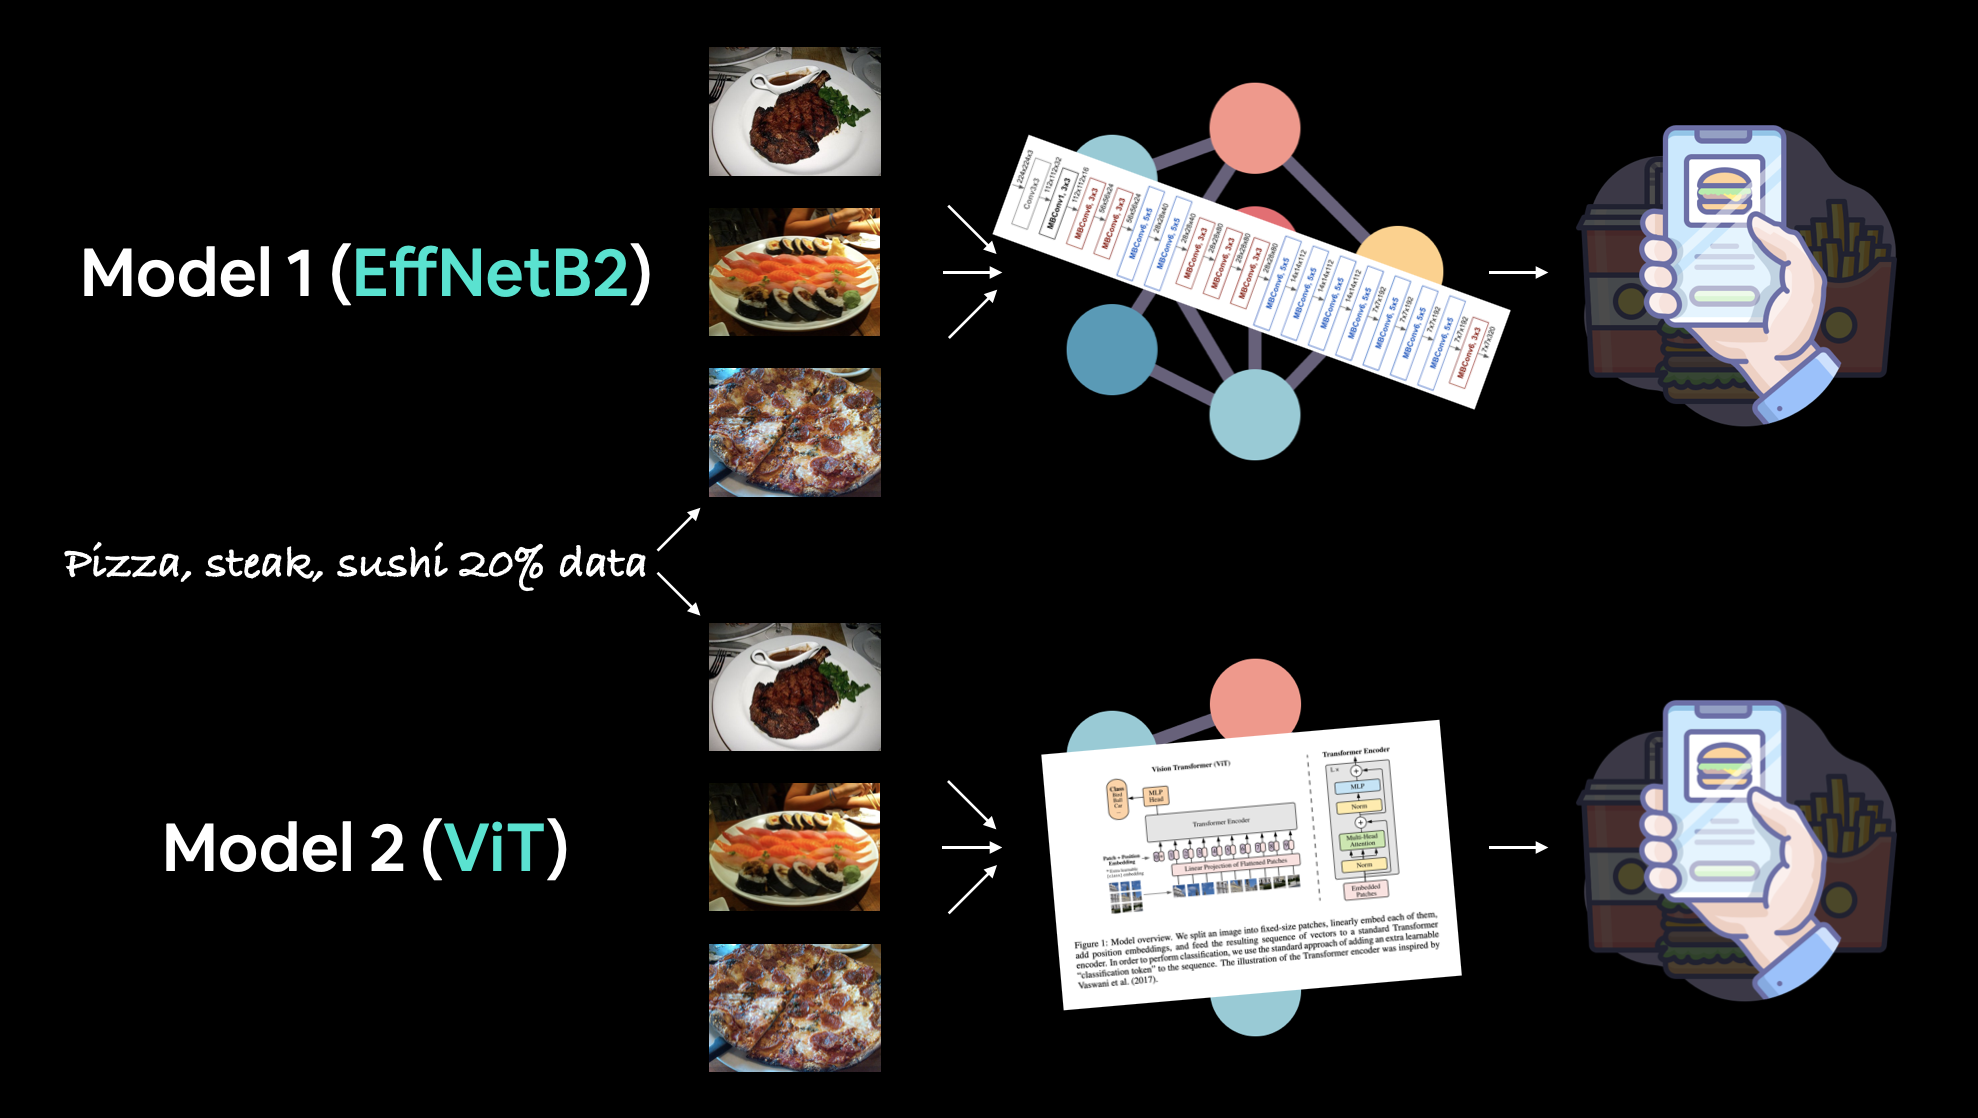

### 3. Creating an EffnetB2 Extractor


We first created an EffNetB2 feature extractor model in 07. PyTorch Experiment Tracking section 7.5.

And by the end of that section we saw it performed very well.

So let's now recreate it here so we can compare its results to a ViT feature extractor trained on the same data.



In [5]:
# 1. Setup pretrained EffNetB2 weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

# 2. Get EffNetB2 transforms
effnetb2_transforms = effnetb2_weights.transforms()

# 3. Setup pretrained model
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights) # could also use weights="DEFAULT"

# 4. Freeze the base layers in the model (this will freeze all layers to begin with)
for param in effnetb2.parameters():
    param.requires_grad = False

In [6]:
#Checking effnetB2 classifier head
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

To Train the model on our dataset we need to replace the out_features to the nummber of classes we have in our dataset i.e 3

In [7]:
# 5. Update the classifier head
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True), # keep dropout layer same
    nn.Linear(in_features=1408, # keep in_features same 
              out_features=3)) # change out_features to suit our number of classes

### 3.1 Creating a fucntion to make an EffnetB2 feature extractor


In [8]:
def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # 1, 2, 3. Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # 4. Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # 5. Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

In [9]:
effnetb2 , effnetb2_transforms = create_effnetb2_model(num_classes=3,seed=42)

In [10]:
from torchinfo import summary
summary(effnetb2,input_size=(1,3,244,244),col_names=["input_size","output_size","num_params","trainable"],
        col_width= 20,row_settings=['var_names'])


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 244, 244]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 244, 244]     [1, 1408, 8, 8]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 244, 244]     [1, 32, 122, 122]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 244, 244]     [1, 32, 122, 122]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 122, 122]    [1, 32, 122, 122]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 122, 122]    [1, 32, 122, 122]    --                   --
│    └─Sequential (1)                                        [1, 32, 122, 122]    [1, 1

### 3.2 Creating Dataloader for EFFnetB2


In [11]:
train_dataloader_effnetb2 , test_dataloader_effnetb2, class_names, class_dict= data_setup.create_dataloaders(train_dir= train_dir,
test_dir= test_dir,train_transform = effnetb2_transforms,test_transform= effnetb2_transforms,batch_size = 32) 

### 3.3 Training EffNetB2 Feature Extractor


In [12]:
%load_ext autoreload
%autoreload 2

import engine

In [13]:
optimizer = torch.optim.Adam(params=effnetb2.parameters(),lr =1e-3)
loss_fn = nn.CrossEntropyLoss()

set_seeds()
effnetb2_results = engine.train(model=effnetb2,train_dataloader = train_dataloader_effnetb2,
test_dataloader = test_dataloader_effnetb2,epochs = 10, optimizer = optimizer,loss_fn = loss_fn,device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9848 | train_acc: 0.5771 | test_loss: 0.7385 | test_acc: 0.9347
Epoch: 2 | train_loss: 0.7111 | train_acc: 0.8521 | test_loss: 0.5865 | test_acc: 0.9409
Epoch: 3 | train_loss: 0.5859 | train_acc: 0.8979 | test_loss: 0.4891 | test_acc: 0.9500
Epoch: 4 | train_loss: 0.4499 | train_acc: 0.9104 | test_loss: 0.4341 | test_acc: 0.9409
Epoch: 5 | train_loss: 0.4278 | train_acc: 0.9083 | test_loss: 0.3921 | test_acc: 0.9443
Epoch: 6 | train_loss: 0.4405 | train_acc: 0.8833 | test_loss: 0.3524 | test_acc: 0.9597
Epoch: 7 | train_loss: 0.4263 | train_acc: 0.8812 | test_loss: 0.3269 | test_acc: 0.9563
Epoch: 8 | train_loss: 0.3836 | train_acc: 0.9083 | test_loss: 0.3478 | test_acc: 0.9352
Epoch: 9 | train_loss: 0.3739 | train_acc: 0.8833 | test_loss: 0.3146 | test_acc: 0.9193
Epoch: 10 | train_loss: 0.3668 | train_acc: 0.8667 | test_loss: 0.2817 | test_acc: 0.9688
